In [1]:
# The competition requires all the tasks to be done in one .ipynb file for code implementation for tasks 1-3
# I will annotate the code with explanation for it and the math behind it

In [2]:
# Task 1: Implement Logistics Regression
# As per requirements sklearn libraries and packages will not be used

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = "50-007-machine-learning-may-2026/"

# First look at the dataset.
# The raw text is not what we actually model on. The competition already gives
# us ready made TF-IDF features in train_features.csv and test_features.csv.
# We look at the text once to understand the task then work from the features.
parse_data = pd.read_csv(DATA + "train.csv")
parse_data.head()


,id,text,label
0,71ec6000-1f20-4850-a8f7-140bc6ad640d,Instance-level video segmentation requires a s...,1
1,9a494ddf-43c6-4c54-8927-f2343054fef2,Samples of high-redshift galaxies are easy to ...,0
2,bc1dc7e4-d773-4c52-bcc1-ed08ba822f92,"Ashley Sibery, 39, persuaded Sital Sibery to t...",1
3,c9f43db6-21b9-4ca6-9830-ce06ff47b950,On-shell methods offer an alternative definiti...,0
4,3c0ef5fb-5311-4185-b773-ea48e7e5bd51,The ocean goes through two tide cycles in a da...,1


In [3]:
# Base idea is to have a classifer that outputs values between 0 and 1
# Implement a sigmoid function to map any number between 0 and 1
# and interpret the results as a probability

# The cost function would then be constructed to maximise the probability
# of correct classification and make it easy to work with

# Implementing the sigmoid function
# The raw formula from the slides can overflow when z gets large, because
# np.exp of a big number blows up. So I use a branched version instead.
# Each branch only takes exp of a negative number, and exp of a negative is
# always between 0 and 1, so it cannot overflow.
# The two branches are the same function, just rearranged. 1/(1+e^-z) is the
# same as e^z/(1+e^z) if you multiply the top and bottom by e^z.
def sigmoid(z):
    out = np.empty_like(z, dtype=float)
    pos = z >= 0            # z is an array so this is an array of true/false
    # this only fills the slots where pos is true
    out[pos] = 1 / (1 + np.exp(-z[pos]))    # z >= 0 so -z is negative, safe
    e = np.exp(z[~pos])                      # z < 0 so this is safe too
    out[~pos] = e / (1 + e)
    return out


# Implement the hypothesis function
# X is the data, w is the weights the model learns, b is the bias.
# y is not passed in, because the hypothesis is our prediction so it should
# never see the real answer.
def hypothesis(X, w, b):
    # X @ w does one dot product per row, giving one score per document.
    # for each row it works out the sum of X[i,j] * w[j], so every word votes
    # weighted by how much of it is in the document. b is then added to each row.
    # without b the line would be forced through the origin and could not capture
    # that the data is about 62.5% class 1.
    return sigmoid(X @ w + b)


# The loss function, binary cross entropy, from the slides.
# It is just the negative log of the probability we gave to the correct answer,
# averaged over all the documents.
# the y and (1-y) work like a switch. y is always 0 or 1 so only one of the two
# terms is left for each document.
def loss(y, y_hat):
    # clip so log never sees exactly 0. if y_hat is exactly 0 or 1 then log(0)
    # is -inf, and 0 times -inf gives nan which ruins the whole average.
    y_hat = np.clip(y_hat, 1e-15, 1 - 1e-15)
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))


# Using gradient descent to find the best values of the parameters
def gradients(X, y, y_hat, w, lam=0.0):
    # X is the input
    # y is the true label
    # y_hat is the prediction
    # w is the weights, needed for the regularisation term
    # lam is the regularisation strength, 0 means no regularisation

    m = X.shape[0]          # number of training examples

    # (y_hat - y) is the error. the sign says which way we were wrong and the
    # size says how wrong. a perfect prediction gives 0.
    # X.T flips the data from being grouped by document to being grouped by word,
    # because the gradient is really a question about each word. X.T @ error then
    # adds up every word's votes across all the documents. if a word is not in a
    # document then X is 0 there so it adds nothing, which is what we want.
    # + lam * w is the L2 regularisation. our data is very sparse and almost
    # separable, so without it the weights would keep growing forever.
    dw = (1 / m) * np.dot(X.T, (y_hat - y)) + lam * w

    # b affects every document in the same way so there is no feature to weight
    # by, it is just the average error. we do not regularise b because it stores
    # the class balance, which is a real fact about the data.
    db = (1 / m) * np.sum(y_hat - y)

    return dw, db


# The train function
def train(X, y, epochs, lr, lam=0.0):
    # epochs is the number of iterations
    # lr is the learning rate, how big a step we take downhill
    # lam is the regularisation strength

    m, n = X.shape

    # start the weights and bias at 0.
    # the loss for logistic regression is convex, meaning one single valley with
    # no local minima, so starting at 0 is fine. neural nets need a random start
    # but we do not.
    w = np.zeros(n)
    b = 0.0
    losses = []

    for i in range(epochs):
        y_hat = hypothesis(X, w, b)                 # predict
        dw, db = gradients(X, y, y_hat, w, lam)     # get the slope
        w -= lr * dw                                # step against the slope
        b -= lr * db
        if i % 50 == 0:
            losses.append(loss(y, y_hat))           # save the loss to look at later

    return w, b, losses


# Turn the probabilities into 0 or 1 labels.
# threshold is kept as a parameter so we can tune it on the validation set later.
# 0.5 is just a default.
def predict(X, w, b, threshold=0.5):
    # .astype(int) is needed, otherwise this returns true/false and pandas would
    # write True and False into the csv instead of 1 and 0.
    return (hypothesis(X, w, b) >= threshold).astype(int)


In [4]:
# Load the features and look at them before doing any modelling.
# The train and test feature files have different layouts:
#     train_features.csv:  id, label, 0001 ... 5000   (5002 cols)
#     test_features.csv:   id,        0001 ... 5000   (5001 cols)
# So indexing by position like iloc[:, 2:] is right for one and wrong for the
# other. Dropping columns by name avoids that problem.

train_df = pd.read_csv(DATA + "train_features.csv")
test_df = pd.read_csv(DATA + "test_features.csv")

X = train_df.drop(columns=["id", "label"]).values
y = train_df["label"].values.astype(float)

X_test = test_df.drop(columns=["id"]).values
test_ids = test_df["id"].values

# Each line below is a decision, not just information:
print("X shape       ", X.shape)          # can I plot this? 5000 features so no
print("X_test shape  ", X_test.shape)     # must match X or w will not apply
print("dtype         ", X.dtype)
print("value range   ", X.min(), X.max()) # all one unit so no normalising needed
print("sparsity      ", (X == 0).mean())  # centering would destroy this
print("per-col std   ", X.std(0).min(), X.std(0).max())   # a 0 here means /0 nan
print("any nan?      ", np.isnan(X).any())
print("class balance ", y.mean())         # this is the baseline we must beat

assert X.shape[1] == X_test.shape[1], "train/test feature count mismatch"


X shape        (20000, 5000)
X_test shape   (6999, 5000)
dtype          float64
value range    0.0 1.0
sparsity       0.98643014
per-col std    0.004512822378628483 0.032841743261190715
any nan?       False
class balance  0.6252


In [5]:
# Hold out a validation set before anything else.
# Stratified means keep the same class balance in both halves. Otherwise the
# validation score partly depends on the luck of the split and not the model.
# Fixed seed so the split is the same every run.

rng = np.random.default_rng(42)

def stratified_split(X, y, val_frac=0.2, rng=rng):
    tr_idx, va_idx = [], []
    for cls in (0, 1):
        idx = np.flatnonzero(y == cls)     # row numbers for this class
        rng.shuffle(idx)
        cut = int(len(idx) * val_frac)
        va_idx.append(idx[:cut])           # first 20% goes to validation
        tr_idx.append(idx[cut:])           # the rest goes to training
    tr = np.concatenate(tr_idx); rng.shuffle(tr)
    va = np.concatenate(va_idx); rng.shuffle(va)
    return X[tr], y[tr], X[va], y[va]

X_tr, y_tr, X_va, y_va = stratified_split(X, y)

print("train", X_tr.shape, "balance %.4f" % y_tr.mean())
print("val  ", X_va.shape, "balance %.4f" % y_va.mean())

# This is the number to beat. Always know it before training so I cannot fool
# myself afterwards. A model scoring under this has learned nothing, even if the
# loss curve looks good.
baseline = max(y_va.mean(), 1 - y_va.mean())
print("majority-class baseline on val: %.4f" % baseline)


train (16001, 5000) balance 0.6252
val   (3999, 5000) balance 0.6252
majority-class baseline on val: 0.6252


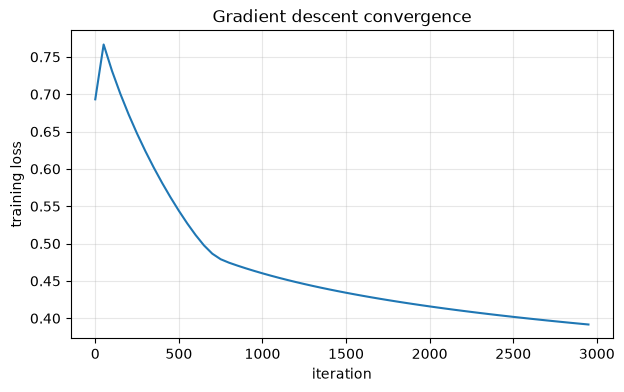

first loss 0.69315  ->  last loss 0.39165


In [6]:
# Train
# lr=10 was found by trying values on the validation set. lr=1 barely moves and
# only learns the class balance, lr=20 and above starts to oscillate.
# Look at the curve and adjust. lam=0 first to get a plain baseline before
# deciding whether regularisation helps.

w, b, losses = train(X_tr, y_tr, epochs=3000, lr=10.0, lam=0.0)

plt.figure(figsize=(7, 4))
plt.plot(np.arange(len(losses)) * 50, losses)
plt.xlabel("iteration")
plt.ylabel("training loss")
plt.title("Gradient descent convergence")
plt.grid(alpha=0.3)
plt.show()

# How to read this plot, it is basically the whole debugging toolkit:
#   smooth going down and flattening means it is working
#   jagged or bouncing means lr too big, try lr / 10
#   nan means lr way too big, try lr / 100
#   nearly flat and barely moving means lr too small, try lr * 10
#   going negative means a sign bug in the loss, cross entropy is always >= 0
print("first loss %.5f  ->  last loss %.5f" % (losses[0], losses[-1]))


In [7]:
# Evaluate against the baseline
# The metrics are written from scratch because sklearn is not allowed here.

def accuracy(y_true, y_pred):
    return (y_true == y_pred).mean()       # fraction of predictions that are correct

def f1(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))   # said 1 and was 1
    fp = np.sum((y_pred == 1) & (y_true == 0))   # said 1 but was 0
    fn = np.sum((y_pred == 0) & (y_true == 1))   # said 0 but was 1
    if tp == 0:
        return 0.0
    prec = tp / (tp + fp)
    rec = tp / (tp + fn)
    return 2 * prec * rec / (prec + rec)

val_pred = predict(X_va, w, b)

print("val accuracy  %.4f    (baseline %.4f)" % (accuracy(y_va, val_pred), baseline))
print("val F1        %.4f" % f1(y_va, val_pred))
print("learned b     %.4f    (log-odds of the class prior ~ %.4f)"
      % (b, np.log(y_tr.mean() / (1 - y_tr.mean()))))

# If the accuracy does not beat the baseline then something is wrong, no matter
# how nice the loss curve looked.


val accuracy  0.7564    (baseline 0.6252)
val F1        0.8149
learned b     0.9431    (log-odds of the class prior ~ 0.5117)


In [8]:
# Tune the decision threshold on the validation set
# 0.5 is just a default. With a 62.5 / 37.5 class balance the best threshold is
# often not 0.5, especially if the competition metric is F1.
# Check the competition page for the metric and then optimise for that column.

probs_va = hypothesis(X_va, w, b)

print(" thresh    acc      f1")
for t in np.arange(0.30, 0.71, 0.05):
    p = (probs_va >= t).astype(int)
    print("   %.2f   %.4f   %.4f" % (t, accuracy(y_va, p), f1(y_va, p)))


 thresh    acc      f1
   0.30   0.7152   0.8082
   0.35   0.7287   0.8126
   0.40   0.7434   0.8179
   0.45   0.7512   0.8188
   0.50   0.7564   0.8149
   0.55   0.7564   0.8068
   0.60   0.7537   0.7953
   0.65   0.7352   0.7681
   0.70   0.7149   0.7361


In [9]:
# Final step, refit on all the data and then predict the test set.
# The validation split was there to choose lr, lam and threshold. Once those are
# chosen, refit on all 20000 rows because more data gives better weights.

THRESHOLD = 0.5      # set this from the threshold sweep above
LAM = 0.0            # set this from the regularisation experiment
LR = 10.0            # from the lr sweep, lr=1 too small and 20+ oscillates

w_final, b_final, losses_final = train(X, y, epochs=3000, lr=LR, lam=LAM)

test_pred = predict(X_test, w_final, b_final, threshold=THRESHOLD)

sub = pd.DataFrame({"id": test_ids, "label": test_pred})
sub.to_csv("LogReg_Prediction.csv", index=False)

print("wrote LogReg_Prediction.csv", sub.shape)
print(sub["label"].value_counts(normalize=True))
sub.head()


wrote LogReg_Prediction.csv (6999, 2)
label
1    0.779826
0    0.220174
Name: proportion, dtype: float64


,id,label
0,59218,1
1,37110,1
2,23200,0
3,e3357348-166e-4847-a06d-158b7cd83aa5,1
4,61615,1
